# Sesión 6 — OPF no lineal (AC-OPF / NLP)

**Objetivo:** Formular y resolver el flujo de potencia óptimo en AC (AC-OPF) como un problema de programación no lineal (NLP) con Pyomo + Ipopt. Comparar con la solución DC-OPF.

**Duración estimada:** 90 minutos

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pandapower as pp
import pandapower.networks as pn
from IPython.display import display

print('Entorno listo ✓')

Entorno listo ✓


---
## 1. Formulación del AC-OPF

El AC-OPF minimiza el coste de generación respetando las leyes de flujo de potencia en AC (ecuaciones no lineales). A diferencia del DC-OPF, considera la **potencia reactiva** y las **pérdidas**.

La no linealidad viene de las ecuaciones de flujo de potencia, que involucran productos de tensiones y senos/cosenos de diferencias de ángulo:

$$P_i = \sum_j |V_i||V_j|(G_{ij}\cos\theta_{ij} + B_{ij}\sin\theta_{ij})$$
$$Q_i = \sum_j |V_i||V_j|(G_{ij}\sin\theta_{ij} - B_{ij}\cos\theta_{ij})$$


In [2]:
# ── Cargar red y extraer Ybus ────────────────────────────────────────────────
net = pn.case14()
pp.runpp(net)

from pandapower.pd2ppc import _pd2ppc
from pandapower.shortcircuit.impedance import _calc_ybus

ppc, ppci = _pd2ppc(net)
_calc_ybus(ppci)
Ybus = ppci['internal']['Ybus'].todense()
Sbase = ppci['baseMVA']
N = len(net.bus)

# Conductancias y susceptancias nodales
G_mat = np.real(Ybus)
B_mat = np.imag(Ybus)

print(f'Red: {N} barras, Sbase = {Sbase} MVA')

Red: 14 barras, Sbase = 100 MVA


In [3]:
# ── Extracción Exacta de Costes para evitar desfases ──────────────────────
gen_data = []

# 1. Procesar Generadores Convencionales (gen)
for idx, row in net.gen.iterrows():
    # Filtro dinámico: buscamos en la tabla de costes el elemento 'idx' que sea tipo 'gen'
    cost_mask = (net.poly_cost.element == idx) & (net.poly_cost.et == 'gen')
    row_cost = net.poly_cost[cost_mask]
    
    # Extraemos valores (si no existen, ponemos 0.0 para evitar errores). Ajustamos coeficientes de coste lineal y cuadraticos
    cp1 = row_cost.cp1_eur_per_mw.values[0] if not row_cost.empty else 0.0
    cp2 = row_cost.cp2_eur_per_mw2.values[0] if not row_cost.empty else 0.0

    gen_data.append({
        'id':      idx, # Mantener ID original para consistencia
        'bus':     row['bus'],
        'p_max':   row['max_p_mw'] / Sbase,
        'p_min':   row['min_p_mw'] / Sbase,
        'q_max':   row.get('max_q_mvar', 100) / Sbase,
        'q_min':   row.get('min_q_mvar', -100) / Sbase,
        'cp1':     cp1,
        'cp2':     cp2
    })

# 2. Procesar el Generador Slack (ext_grid)
for idx, row in net.ext_grid.iterrows():
    cost_mask = (net.poly_cost.element == idx) & (net.poly_cost.et == 'ext_grid')
    row_cost = net.poly_cost[cost_mask]
    
    cp1 = row_cost.cp1_eur_per_mw.values[0] if not row_cost.empty else 0.0
    cp2 = row_cost.cp2_eur_per_mw2.values[0] if not row_cost.empty else 0.0

    gen_data.append({
        'id':      f"slack_{idx}",
        'bus':     row['bus'],
        'p_max':   1000 / Sbase,
        'p_min':   -1000 / Sbase,
        'q_max':   1000 / Sbase,
        'q_min':   -1000 / Sbase,
        'cp1':     cp1,
        'cp2':     cp2
    })

df_gen = pd.DataFrame(gen_data)
display(df_gen)


# Cargas en pu
P_load = np.zeros(N)
Q_load = np.zeros(N)
for _, row in net.load.iterrows():
    P_load[row['bus']] += row['p_mw'] / Sbase
    Q_load[row['bus']] += row.get('q_mvar', 0) / Sbase

,id,bus,p_max,p_min,q_max,q_min,cp1,cp2
0,0,1,1.4,0.0,0.50,-0.40,20.0,0.250000
1,1,2,1.0,0.0,0.40,0.00,40.0,0.010000
2,2,5,1.0,0.0,0.24,-0.06,40.0,0.010000
3,3,7,1.0,0.0,0.24,-0.06,40.0,0.010000
4,slack_0,0,10.0,-10.0,10.00,-10.00,20.0,0.043029


---
## 2. Modelo Pyomo del AC-OPF

In [4]:
modelo = pyo.ConcreteModel(name='AC-OPF IEEE14')

# Conjuntos
modelo.buses = pyo.Set(initialize=list(range(N)))
modelo.gens  = pyo.Set(initialize=list(df_gen['id']))

# Parámetros de Ybus
modelo.G_mat = pyo.Param(modelo.buses, modelo.buses,
                         initialize={(i, j): float(G_mat[i, j]) for i in range(N) for j in range(N)})
modelo.B_mat = pyo.Param(modelo.buses, modelo.buses,
                         initialize={(i, j): float(B_mat[i, j]) for i in range(N) for j in range(N)})

# Parámetros de cargas
modelo.Pd = pyo.Param(modelo.buses, initialize={i: float(P_load[i]) for i in range(N)})
modelo.Qd = pyo.Param(modelo.buses, initialize={i: float(Q_load[i]) for i in range(N)})

# Parámetros de generadores
modelo.p_max   = pyo.Param(modelo.gens, initialize={r['id']: r['p_max'] for _, r in df_gen.iterrows()})
modelo.p_min   = pyo.Param(modelo.gens, initialize={r['id']: r['p_min'] for _, r in df_gen.iterrows()})
modelo.q_max   = pyo.Param(modelo.gens, initialize={r['id']: r['q_max'] for _, r in df_gen.iterrows()})
modelo.q_min   = pyo.Param(modelo.gens, initialize={r['id']: r['q_min'] for _, r in df_gen.iterrows()})
modelo.cp1   = pyo.Param(modelo.gens, initialize={r['id']: r['cp1']  for _, r in df_gen.iterrows()})
modelo.cp2   = pyo.Param(modelo.gens, initialize={r['id']: r['cp2']  for _, r in df_gen.iterrows()})
modelo.gen_bus = pyo.Param(modelo.gens, initialize={r['id']: r['bus']    for _, r in df_gen.iterrows()})

# Variables
modelo.V     = pyo.Var(modelo.buses, bounds=(0.9, 1.1), initialize=1.0)  # módulo de tensión [pu]
modelo.theta = pyo.Var(modelo.buses, bounds=(-np.pi, np.pi), initialize=0.0)  # ángulo [rad]
modelo.Pg    = pyo.Var(modelo.gens, bounds=lambda m, g: (pyo.value(m.p_min[g]), pyo.value(m.p_max[g])))
modelo.Qg    = pyo.Var(modelo.gens, bounds=lambda m, g: (pyo.value(m.q_min[g]), pyo.value(m.q_max[g])))

# Bus slack: ángulo fijo a 0 y tensión fija al valor nominal
modelo.theta[0].fix(0.0)
modelo.V[0].fix(1.06)   # tensión nominal de la barra 1 en IEEE14

# Función objetivo
def fo(m):
    return sum(m.cp1[g] * m.Pg[g]*Sbase + m.cp2[g] * (m.Pg[g]*Sbase)**2 for g in m.gens)
modelo.obj = pyo.Objective(rule=fo, sense=pyo.minimize)

print('Variables y objetivo definidos ✓')

Variables y objetivo definidos ✓


In [5]:
# ── Restricciones de balance nodal (no lineal) ────────────────────────────────
#
# Balance P: sum_g(Pg) - Pd[i] = sum_j V[i]*V[j]*(G[i,j]*cos(θ[i]-θ[j]) + B[i,j]*sin(θ[i]-θ[j]))
# Balance Q: sum_g(Qg) - Qd[i] = sum_j V[i]*V[j]*(G[i,j]*sin(θ[i]-θ[j]) - B[i,j]*cos(θ[i]-θ[j]))

def balance_P(m, i):
    gen_P = sum(m.Pg[g] for g in m.gens if pyo.value(m.gen_bus[g]) == i)
    inyec = sum(
        m.V[i] * m.V[j] * (
            m.G_mat[i, j] * pyo.cos(m.theta[i] - m.theta[j]) +
            m.B_mat[i, j] * pyo.sin(m.theta[i] - m.theta[j])
        )
        for j in m.buses
    )
    return gen_P - m.Pd[i] == inyec

def balance_Q(m, i):
    gen_Q = sum(m.Qg[g] for g in m.gens if pyo.value(m.gen_bus[g]) == i)
    inyec = sum(
        m.V[i] * m.V[j] * (
            m.G_mat[i, j] * pyo.sin(m.theta[i] - m.theta[j]) -
            m.B_mat[i, j] * pyo.cos(m.theta[i] - m.theta[j])
        )
        for j in m.buses
    )
    return gen_Q - m.Qd[i] == inyec

modelo.r_balance_P = pyo.Constraint(modelo.buses, rule=balance_P)
modelo.r_balance_Q = pyo.Constraint(modelo.buses, rule=balance_Q)

print('Restricciones de balance nodal definidas ✓')
print(f'Total restricciones: {modelo.nconstraints()}')

Restricciones de balance nodal definidas ✓
Total restricciones: 28


In [6]:
# ── Resolver con Ipopt ───────────────────────────────────────────────────────
solver = pyo.SolverFactory('ipopt')
solver.options['max_iter'] = 500
solver.options['tol'] = 1e-8

resultado = solver.solve(modelo, tee=True)

print('\nEstado:', resultado.solver.termination_condition)
print(f'Coste óptimo AC-OPF: {pyo.value(modelo.obj):.2f} €/h')

Ipopt 3.14.19: max_iter=500
tol=1e-08


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:      214
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      116

Total number of variables............................:       36
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       36
                     variables with only upper bounds:        0
Total number of equality constraints.................

In [7]:
# Creamos una lista para almacenar los resultados de los generadores
res_gens = []

for g in modelo.gens:
    # Calculamos los valores reales para facilitar la lectura
    p_mw = pyo.value(modelo.Pg[g]) * Sbase
    q_mvar = pyo.value(modelo.Qg[g]) * Sbase
    
    # Extraemos los coeficientes de coste
    c1 = pyo.value(modelo.cp1[g])
    c2 = pyo.value(modelo.cp2[g])
    
    # Calculamos el coste total: cp2*P^2 + cp1*P
    coste_total = c2 * (p_mw**2) + c1 * p_mw

    res_gens.append({
        'ID Generador': g,
        'Barra':        int(pyo.value(modelo.gen_bus[g])),
        'P [MW]':       p_mw,
        'Q [Mvar]':     q_mvar,
        'P_max [MW]':   pyo.value(modelo.p_max[g]) * Sbase,
        'cp1 [€/MW]':   c1,
        'cp2 [€/MW²]':  c2,
        'Coste (€/h)':  coste_total
    })

# Crear DataFrame y ordenar por Barra
df_res_gens = pd.DataFrame(res_gens).sort_values(by='Barra')

print("\n" + "="*50)
print("       RESULTADOS DE GENERACIÓN (CUADRÁTICO)       ")
print("="*50)
display(df_res_gens.round(3))

# Verificación del coste total del sistema
coste_total_sistema = df_res_gens['Coste (€/h)'].sum()
print(f"\nCoste Total de Operación: {coste_total_sistema:.2f} €/h")


       RESULTADOS DE GENERACIÓN (CUADRÁTICO)       


,ID Generador,Barra,P [MW],Q [Mvar],P_max [MW],cp1 [€/MW],cp2 [€/MW²],Coste (€/h)
4,slack_0,0,194.566,-15.280,1000.0,20.0,0.043,5520.233
0,0,1,36.775,25.665,140.0,20.0,0.250,1073.606
1,1,2,28.644,22.132,100.0,40.0,0.010,1153.979
2,2,5,-0.000,16.622,100.0,40.0,0.010,-0.000
3,3,7,8.236,17.029,100.0,40.0,0.010,330.103



Coste Total de Operación: 8077.92 €/h


,Bus,V_Base,V_OPF,Dif_abs
0,0,1.0600,1.0600,0.0000
1,1,1.0450,1.0465,0.0015
2,2,1.0100,1.0233,0.0133
3,3,1.0177,1.0269,0.0092
4,4,1.0195,1.0276,0.0081
5,5,1.0700,1.0849,0.0149
6,6,1.0615,1.0728,0.0113
7,7,1.0900,1.1000,0.0100
8,8,1.0559,1.0689,0.0129
9,9,1.0510,1.0644,0.0134


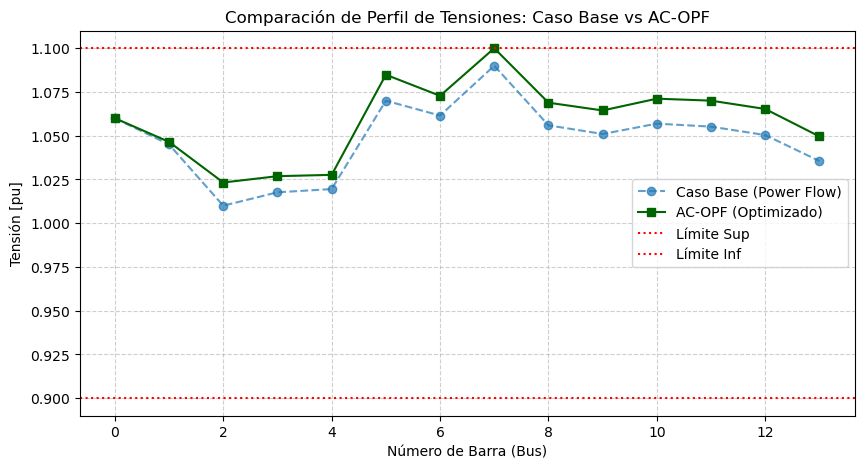

<Figure size 640x480 with 0 Axes>

Pérdidas caso base: 13.39 MW
Pérdidas AC-OPF:   9.22 MW
Reducción de pérdidas: 31.15%


In [8]:
# ── Comparar perfiles de tensión: caso base vs AC-OPF ───────────────────────
v_base = net.res_bus['vm_pu'].values
v_opf  = np.array([pyo.value(modelo.V[i]) for i in range(N)])


# Creamos un DataFrame para comparar
df_tensiones = pd.DataFrame({
    'Bus': list(modelo.buses),
    'V_Base': v_base,
    'V_OPF': v_opf
})

# Calculamos la diferencia
df_tensiones['Dif_abs'] = (df_tensiones['V_OPF'] - df_tensiones['V_Base']).abs()

display(df_tensiones.round(4))
# % TODO: representa ambos perfiles en la misma figura

plt.figure(figsize=(10, 5))
plt.plot(df_tensiones['Bus'], df_tensiones['V_Base'], 'o--', label='Caso Base (Power Flow)', alpha=0.7)
plt.plot(df_tensiones['Bus'], df_tensiones['V_OPF'], 's-', label='AC-OPF (Optimizado)', color='darkgreen')

# Añadimos límites de seguridad
plt.axhline(y=1.1, color='r', linestyle=':', label='Límite Sup')
plt.axhline(y=0.9, color='r', linestyle=':', label='Límite Inf')

plt.title('Comparación de Perfil de Tensiones: Caso Base vs AC-OPF')
plt.xlabel('Número de Barra (Bus)')
plt.ylabel('Tensión [pu]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

plt.savefig('./resultados/sesion06_tension_opf_vs_base.png', dpi=150)
plt.show()

# TODO: calcula las pérdidas totales en el caso base y en el OPF
perdidas_base = net.res_line['pl_mw'].sum()

# 2. Cálculo de pérdidas en el OPF - Potencia activa generada - Potencia activa demandada
p_gen_total_pu = sum(pyo.value(modelo.Pg[g]) for g in modelo.gens)
p_load_total_pu = sum(pyo.value(modelo.Pd[i]) for i in modelo.buses)

# Convertimos a MW usando la Sbase
perdidas_opf = (p_gen_total_pu - p_load_total_pu) * Sbase

print(f'Pérdidas caso base: {perdidas_base:.2f} MW')
print(f'Pérdidas AC-OPF:   {perdidas_opf:.2f} MW')
print(f'Reducción de pérdidas: {((perdidas_base - perdidas_opf)/perdidas_base)*100:.2f}%')

---
## 3. OPF con Pandapower (verificación)

Pandapower incluye su propio solver de OPF basado en PYPOWER. Lo usamos para verificar la solución de nuestro modelo.

In [9]:
# Añadir costes de generación en la red de pandapower
net_opf = pn.case14()

# Límites de tensión
net_opf.bus['max_vm_pu'] = 1.1
net_opf.bus['min_vm_pu'] = 0.9

# Resolver OPF
try:
    pp.runopp(net_opf, delta=1e-8)
    print(f'Coste OPF Pandapower: {net_opf.res_cost:.2f} €/h')
    display(net_opf.res_bus[['vm_pu', 'va_degree']].round(4))
except Exception as e:
    print(f'Error: {e}')

Coste OPF Pandapower: 8079.23 €/h


,vm_pu,va_degree
0,1.0600,0.0000
1,1.0393,-3.9920
2,1.0162,-9.8963
3,1.0210,-8.7609
4,1.0220,-7.5108
5,1.0765,-12.6449
6,1.0688,-11.2549
7,1.1000,-10.5515
8,1.0634,-12.9973
9,1.0584,-13.2165


In [10]:
# ── Resultados de Generación en Pandapower ──────────────────────────────────

if net_opf.OPF_converged:
    print("\n" + "="*40)
    print("   SOLUCIÓN DE GENERACIÓN (PANDAPOWER)   ")
    print("="*40)

    # 1. Potencia del Generador Slack (ext_grid)
    # En pandapower, el slack se encuentra en net.res_ext_grid
    df_slack = net_opf.res_ext_grid[['p_mw', 'q_mvar']].copy()
    df_slack['type'] = 'Slack (ext_grid)'
    df_slack['bus'] = net_opf.ext_grid['bus'].values
    
    # 2. Potencia de los Generadores (gen)
    df_gens = net_opf.res_gen[['p_mw', 'q_mvar']].copy()
    df_gens['type'] = 'Generator (gen)'
    df_gens['bus'] = net_opf.gen['bus'].values

    # Concatenar ambos para una vista unificada
    res_total = pd.concat([df_slack, df_gens])
    
    # Reordenar columnas para mejor lectura
    res_total = res_total[['bus', 'type', 'p_mw', 'q_mvar']]
    
    display(res_total.round(3))
    
    # Verificación de Balance
    p_gen_total = res_total['p_mw'].sum()
    p_load_total = net_opf.load['p_mw'].sum()
    print(f"\nGeneración Total: {p_gen_total:.2f} MW")
    print(f"Demanda Total:    {p_load_total:.2f} MW")
    print(f"Pérdidas:         {p_gen_total - p_load_total:.2f} MW")
else:
    print("El OPF no convergió. Revisa los límites o los costes.")


   SOLUCIÓN DE GENERACIÓN (PANDAPOWER)   


,bus,type,p_mw,q_mvar
0,0,Slack (ext_grid),194.426,0.000
0,1,Generator (gen),36.741,11.189
1,2,Generator (gen),28.876,21.583
2,5,Generator (gen),0.000,14.701
3,7,Generator (gen),8.195,19.546



Generación Total: 268.24 MW
Demanda Total:    259.00 MW
Pérdidas:         9.24 MW


In [11]:
# Ver la tabla de costes polinómicos
if not net.poly_cost.empty:
    print("Costes cargados correctamente:")
    display(net.poly_cost)
else:
    print("La tabla está vacía. Necesitas inicializar los costes.")

net.poly_cost.drop(net.poly_cost.index, inplace=True)

# 1. Añadir coste al Slack (ext_grid)
# Buscamos el índice del slack (normalmente es 0)
for idx in net.ext_grid.index:
    pp.create_poly_cost(net, element=idx, et='ext_grid', cp1_eur_per_mw=20)

# 2. Añadir costes a los generadores convencionales (gen)
for idx in net.gen.index:
    # Asignamos un coste lineal de 30 €/MWh a todos los generadores
    pp.create_poly_cost(net, element=idx, et='gen', cp1_eur_per_mw=30)

print("Nueva tabla net.poly_cost:")
display(net.poly_cost)

Costes cargados correctamente:


,element,et,cp0_eur,cp1_eur_per_mw,cp2_eur_per_mw2,cq0_eur,cq1_eur_per_mvar,cq2_eur_per_mvar2
0,0,ext_grid,0.0,20.0,0.043029,0.0,0.0,0.0
1,0,gen,0.0,20.0,0.250000,0.0,0.0,0.0
2,1,gen,0.0,40.0,0.010000,0.0,0.0,0.0
3,2,gen,0.0,40.0,0.010000,0.0,0.0,0.0
4,3,gen,0.0,40.0,0.010000,0.0,0.0,0.0


Nueva tabla net.poly_cost:


,element,et,cp0_eur,cp1_eur_per_mw,cp2_eur_per_mw2,cq0_eur,cq1_eur_per_mvar,cq2_eur_per_mvar2
0,0,ext_grid,0.0,20.0,0.0,0.0,0.0,0.0
1,0,gen,0.0,30.0,0.0,0.0,0.0,0.0
2,1,gen,0.0,30.0,0.0,0.0,0.0,0.0
3,2,gen,0.0,30.0,0.0,0.0,0.0,0.0
4,3,gen,0.0,30.0,0.0,0.0,0.0,0.0


---
## Tareas

_Responde brevemente en esta celda:_

1. Compara el coste del AC-OPF con el del DC-OPF (sesión 3). ¿Cuál es mayor? ¿Por qué?

El AC-OPF es mayor que el DC-OPF. La razon es que el DC-OPF no toma en cuenta las perdidas de potencia activa. Ademas, tampoco toma en cuenta las tensiones o flujos de potencia reactiva. Por otro lado, el  AC-OPF si toma en cuenta estos factores, por ende, debe encontrar una solucion que cubra tanto la demanda como las perdidas. Al tomar en cuenta una solucion que tambien cumpla las restricciones fisicas de los flujos de potencia, el punto óptimo de solución se desplaza hacia una zona de mayor coste.


2. Añade las restricciones de flujo de potencia por las líneas (limitando el flujo máximo permitido). 

Puede notarse que el coste optimo aumenta ligeramente. Esto indica que los limites de flujo por las lineas influyen como factor de decision en el costo optimo. Notamos que la linea que satura es la que une la barra 0 a la 1. Esto fuerza al sistema a redistribuir los flujos de energia por otras lineas y tiene un impacto en el costo.


3. Bloquea la tensión en los buses PV al valor original de la red y compara los resultados con el caso sin esta restricción. ¿Cómo afecta esto al coste y a las tensiones en la red?

Al fijar las tensiones en los PV notamos que los valores de tension estan por debajo de los que el OPF sin restriccion fija para los voltajes PV. Esto implica que las corrientes sean mas elevadas, y por ende, las pérdidas también. Al elevar las pérdidas, el coste también incrementará dado que los generadores deben cubrir ese excedente de demanda.Notamos igualmente que el costo entonces sube ligeramente respecto al caso inicial


In [12]:
# ── Datos de líneas (capacidad y conexiones) ───────────────────────────────
line_data = []
for idx, row in net.line.iterrows():
    # Buscamos la capacidad en MVA. Si no existe, usamos un valor alto por defecto.

    s_max = row.get('sn_mva', 100) / Sbase 
    
    line_data.append({
        'id': idx,
        'from': int(row['from_bus']),
        'to': int(row['to_bus']),
        's_max': s_max,
        'g': G_mat[row['from_bus'], row['to_bus']], # Simplificación usando Ybus
        'b': B_mat[row['from_bus'], row['to_bus']]
    })
df_line = pd.DataFrame(line_data)

# Añadimos al modelo de Pyomo
modelo.lines = pyo.Set(initialize=list(df_line['id']))
modelo.line_from = pyo.Param(modelo.lines, initialize=df_line.set_index('id')['from'].to_dict())
modelo.line_to = pyo.Param(modelo.lines, initialize=df_line.set_index('id')['to'].to_dict())
modelo.s_max = pyo.Param(modelo.lines, initialize=df_line.set_index('id')['s_max'].to_dict())

# ── Restricciones de flujo de potencia ──────────────────────────────────────
def limite_flujo_linea(m, l):
    i = m.line_from[l]
    j = m.line_to[l]
    
    # G y B de la línea específica (Viene de la Ybus o parámetros de línea)
    g_ij = m.G_mat[i, j]
    b_ij = m.B_mat[i, j]
    g_sh = 0 # Conductancia shunt si existiera
    b_sh = 0 # Susceptancia shunt (line charging) si existiera

    # Potencia activa de i -> j
    p_ij = (m.V[i]**2 * (-g_ij + g_sh) + 
            m.V[i] * m.V[j] * (g_ij * pyo.cos(m.theta[i] - m.theta[j]) + 
                               b_ij * pyo.sin(m.theta[i] - m.theta[j])))
    
    # Potencia reactiva de i -> j
    q_ij = (m.V[i]**2 * (b_ij - b_sh) + 
            m.V[i] * m.V[j] * (-b_ij * pyo.cos(m.theta[i] - m.theta[j]) + 
                                g_ij * pyo.sin(m.theta[i] - m.theta[j])))
    
    # S^2 <= S_max^2 (evitamos la raíz cuadrada por estabilidad numérica)
    return p_ij**2 + q_ij**2 <= m.s_max[l]**2


modelo.r_flujo_lineas = pyo.Constraint(modelo.lines, rule=limite_flujo_linea)
print('Restricciones de flujo de líneas añadidas ✓')
print(f'Total restricciones: {modelo.nconstraints()}')

Restricciones de flujo de líneas añadidas ✓
Total restricciones: 43


In [13]:
# ── Resolver con Ipopt ───────────────────────────────────────────────────────
solver = pyo.SolverFactory('ipopt')
solver.options['max_iter'] = 500
solver.options['tol'] = 1e-8

resultado_lineas = solver.solve(modelo, tee=True)

print('\nEstado:', resultado_lineas.solver.termination_condition)
print(f'Coste óptimo AC-OPF: {pyo.value(modelo.obj):.2f} €/h')

Ipopt 3.14.19: max_iter=500
tol=1e-08


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:      214
Number of nonzeros in inequality constraint Jacobian.:       56
Number of nonzeros in Lagrangian Hessian.............:      116

Total number of variables............................:       36
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       36
                     variables with only upper bounds:        0
Total number of equality constraints.................


--- Estado de Carga de las Líneas ---


,Línea,De,A,P [MW],Q [Mvar],S [MVA],Carga [%]
0,0,0,1,99.99,-1.55,100.00,100.00
1,1,0,4,54.20,3.58,54.32,54.32
3,3,1,3,42.36,-4.32,42.58,42.58
2,2,1,2,40.77,0.57,40.78,40.78
6,6,3,4,-38.08,11.17,39.68,39.68
4,4,1,4,33.52,-2.15,33.59,33.59
9,9,5,12,16.42,8.38,18.43,18.43
11,11,8,13,11.02,2.05,11.21,11.21
10,10,8,9,7.86,1.86,8.08,8.08
8,8,5,11,7.51,2.85,8.03,8.03


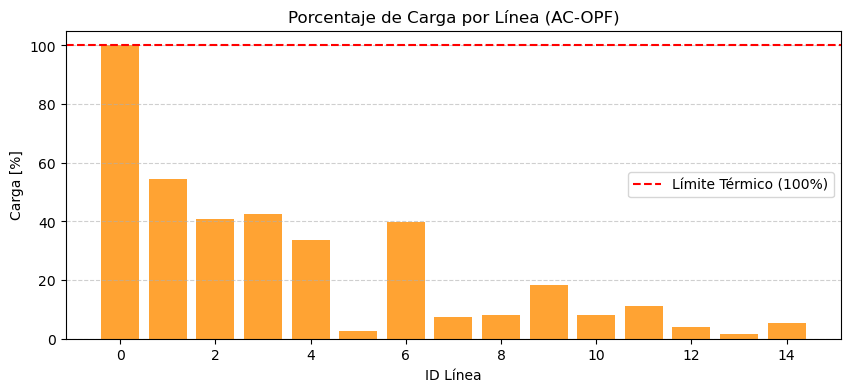

In [14]:
# ── Visualización de la carga por las líneas ────────────────────────────────
res_lineas = []

for l in modelo.lines:
    i, j = pyo.value(modelo.line_from[l]), pyo.value(modelo.line_to[l])
    
    # Extraer valores del modelo resuelto
    Vi, Vj = pyo.value(modelo.V[i]), pyo.value(modelo.V[j])
    Ti, Tj = pyo.value(modelo.theta[i]), pyo.value(modelo.theta[j])
    g_ij, b_ij = pyo.value(modelo.G_mat[i, j]), pyo.value(modelo.B_mat[i, j])
    s_max_pu = pyo.value(modelo.s_max[l])

    # Cálculo de flujos (p.u.)
    p_ij = (Vi**2 * -g_ij) + Vi*Vj*(g_ij*np.cos(Ti-Tj) + b_ij*np.sin(Ti-Tj))
    q_ij = (Vi**2 * b_ij) + Vi*Vj*(-b_ij*np.cos(Ti-Tj) + g_ij*np.sin(Ti-Tj))
    s_ij = np.sqrt(p_ij**2 + q_ij**2)
    
    res_lineas.append({
        'Línea': l,
        'De': i, 'A': j,
        'P [MW]': p_ij * Sbase,
        'Q [Mvar]': q_ij * Sbase,
        'S [MVA]': s_ij * Sbase,
        'Carga [%]': (s_ij / s_max_pu) * 100
    })

df_carga_lineas = pd.DataFrame(res_lineas)

# Mostrar tabla con formato
print("\n--- Estado de Carga de las Líneas ---")
display(df_carga_lineas.sort_values(by='Carga [%]', ascending=False).round(2))

# Visualización rápida de congestión
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(df_carga_lineas['Línea'], df_carga_lineas['Carga [%]'], color='darkorange', alpha=0.8)
plt.axhline(y=100, color='red', linestyle='--', label='Límite Térmico (100%)')
plt.title('Porcentaje de Carga por Línea (AC-OPF)')
plt.ylabel('Carga [%]')
plt.xlabel('ID Línea')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Bloqueando tensiones en buses PV: [1, 2, 5, 7]
Ipopt 3.14.19: max_iter=500
tol=1e-08


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:      184
Number of nonzeros in inequality constraint Jacobian.:       47
Number of nonzeros in Lagrangian Hessian.............:       89

Total number of variables............................:       32
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       32
                     variables with only upper bounds:        0
Total 

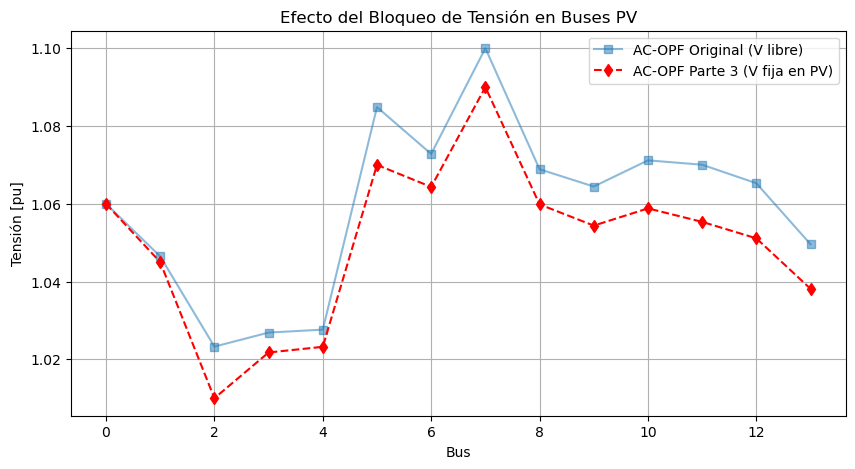

In [15]:
# ── PARTE 3: Bloquear tensiones en buses PV ──────────────────────────────────

# 1. Identificar buses con generadores (PV) excluyendo el slack que ya está fijo
# net.gen['bus'] nos da los buses 1, 2, 5 y 7
buses_pv = net.gen['bus'].tolist()

print(f"Bloqueando tensiones en buses PV: {buses_pv}")

for b in buses_pv:
    # Tomamos el valor de tensión original de la red (caso base)
    v_original = net.res_bus.loc[b, 'vm_pu']
    
    # Usamos .fix() para convertir la variable en una constante para el solver
    modelo.V[b].fix(v_original)

# 2. Resolver el modelo con las nuevas restricciones de tensión
resultado_pv_fijo = solver.solve(modelo, tee=True)

coste_pv_fijo = pyo.value(modelo.obj)
print(f'\nCoste óptimo con buses PV fijos: {coste_pv_fijo:.2f} €/h')
print(f'Diferencia de coste: {coste_pv_fijo - 5674.30:.2f} €/h')

# 3. Extraer nuevos resultados para comparar
v_opf_fijo = np.array([pyo.value(modelo.V[i]) for i in range(N)])

# Comparación visual
plt.figure(figsize=(10, 5))
plt.plot(range(N), v_opf, 's-', label='AC-OPF Original (V libre)', alpha=0.5)
plt.plot(range(N), v_opf_fijo, 'd--', label='AC-OPF Parte 3 (V fija en PV)', color='red')
plt.title('Efecto del Bloqueo de Tensión en Buses PV')
plt.xlabel('Bus')
plt.ylabel('Tensión [pu]')
plt.grid(True)
plt.legend()
plt.show()